# 01. EDA — ETT オイル温度データの探索

目的: モデル設計に直結する問いに答える。

1. 温度はどれくらい「予測しやすい」か(持続性・周期性・トレンド)
2. 負荷変数は温度の先行指標になるか(ラグ相関)
3. 数時間で温度はどれくらい動くか(リスク警告の対象イベント)
4. データ品質の問題はあるか

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf

from ettpoc.data import FEATURE_COLS, flag_artifacts, load_ett

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})
FIG = "../reports/figures"
data = {n: load_ett(n) for n in ["ETTh1", "ETTh2"]}
flags = {n: flag_artifacts(df) for n, df in data.items()}
for n, df in data.items():
    print(n, df.shape, df.index.min(), "->", df.index.max(), "| artifact rows:", flags[n].sum())

ETTh1 (17420, 7) 2016-07-01 00:00:00 -> 2018-06-26 19:00:00 | artifact rows: 437
ETTh2 (17420, 7) 2016-07-01 00:00:00 -> 2018-06-26 19:00:00 | artifact rows: 373


## 1. 全期間の温度推移 — 2 台の変圧器はまったく違う挙動

* **ETTh1**: 2016 年夏 34℃ → 2018 年夏 10℃ と、季節性とは別に **2 年間で大きく低下するトレンド**がある。負荷(HUFL)も同時期に半減しており、設備の運用状態が変わったと考えられる。
* **ETTh2**: 年周期が安定しており、毎夏 40℃超・最大 59℃に達する。

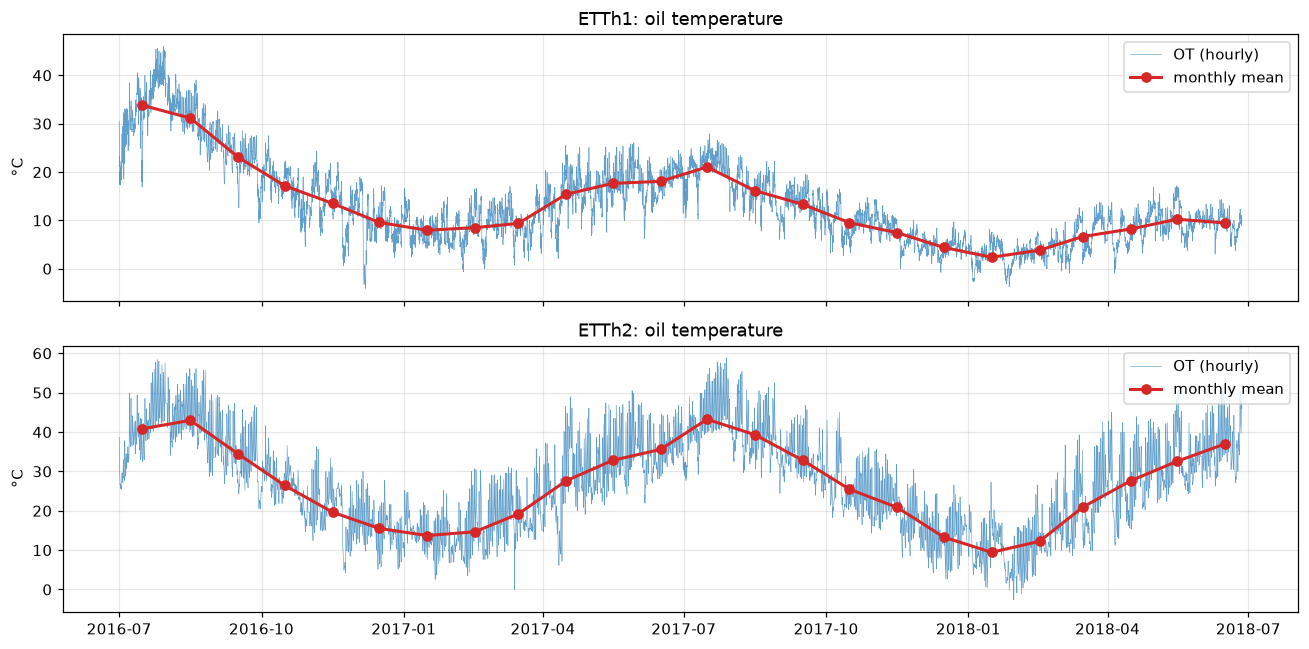

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, (n, df) in zip(axes, data.items()):
    ax.plot(df.index, df.OT, lw=0.4, alpha=0.7, label="OT (hourly)")
    ax.plot(df.OT.resample("MS").mean().index + pd.Timedelta(days=15), df.OT.resample("MS").mean(), "o-", c="C3", lw=2, label="monthly mean")
    ax.set_title(f"{n}: oil temperature"); ax.set_ylabel("°C"); ax.legend(loc="upper right")
plt.tight_layout(); plt.savefig(f"{FIG}/eda_ot_overview.png"); plt.show()

In [3]:
monthly = pd.DataFrame({f"{n}_OT": df.OT.resample("MS").mean() for n, df in data.items()}
                       | {f"{n}_HUFL": df.HUFL.resample("MS").mean() for n, df in data.items()})
monthly.index = monthly.index.strftime("%Y-%m")
monthly.round(1).T

date,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,...,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06
ETTh1_OT,33.8,31.1,23.0,17.2,13.5,9.6,8.0,8.5,9.4,15.4,...,13.3,9.5,7.4,4.4,2.4,3.8,6.7,8.2,10.2,9.5
ETTh2_OT,40.8,43.0,34.4,26.4,19.6,15.5,13.7,14.7,19.2,27.6,...,32.8,25.5,20.8,13.3,9.4,12.2,20.9,27.6,32.6,37.0
ETTh1_HUFL,11.9,12.9,9.0,8.6,9.2,9.1,9.0,7.2,6.6,3.9,...,5.3,5.3,5.8,8.2,10.9,7.7,6.1,5.6,6.2,5.8
ETTh2_HUFL,47.0,47.7,40.4,39.9,39.7,45.7,45.7,44.1,45.7,43.4,...,34.3,29.9,32.9,35.6,42.7,29.6,28.9,24.6,28.5,31.4


## 2. 持続性と周期性 — 「1 時間後はほぼ今と同じ」、日内周期は h2 で強い

* ACF(lag 1) は両方 0.99 超。**直前値の持続(persistence)が非常に強いベースライン**になる。
* 1 時間差分の ACF を見ると、**ETTh1 はほぼホワイトノイズ(ランダムウォークに近い)**。ETTh2 は差分にも lag1=0.68・lag24=0.61 の構造が残り、**日内周期が予測に使える**。
* 日内振幅: ETTh1 ±1.4℃、ETTh2 ±5℃。曜日効果はどちらも無い(0.0)。

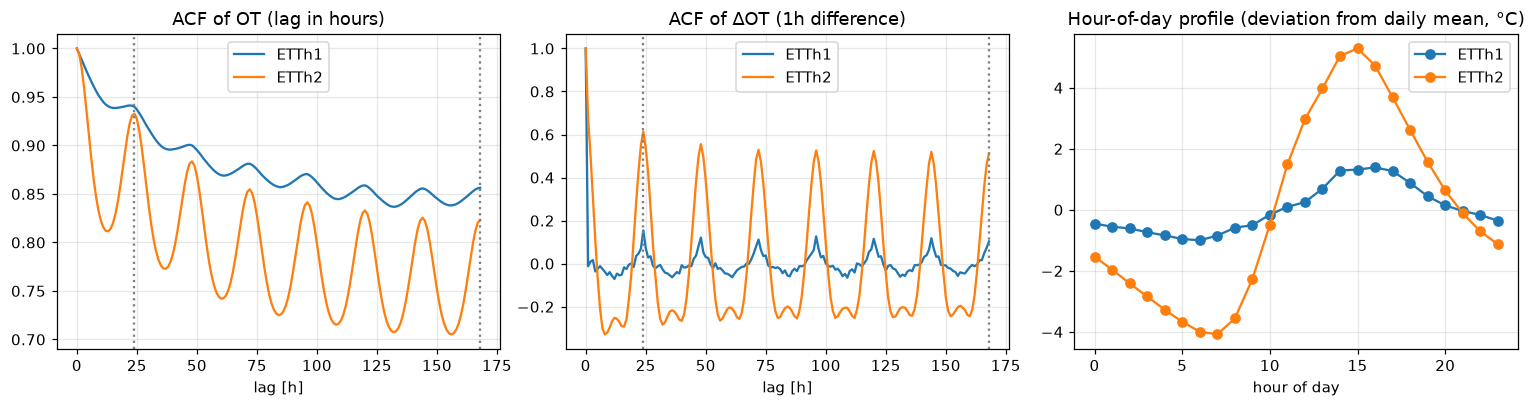

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for n, df in data.items():
    ot = df.OT
    a = acf(ot, nlags=168); ad = acf(ot.diff().dropna(), nlags=168)
    axes[0].plot(a, label=n); axes[1].plot(ad, label=n)
    dev = ot - ot.groupby(ot.index.date).transform("mean")
    axes[2].plot(dev.groupby(ot.index.hour).mean(), "o-", label=n)
axes[0].set_title("ACF of OT (lag in hours)"); axes[1].set_title("ACF of ΔOT (1h difference)"); axes[2].set_title("Hour-of-day profile (deviation from daily mean, °C)")
for ax in axes[:2]:
    ax.axvline(24, c="gray", ls=":"); ax.axvline(168, c="gray", ls=":"); ax.set_xlabel("lag [h]")
axes[2].set_xlabel("hour of day")
for ax in axes: ax.legend()
plt.tight_layout(); plt.savefig(f"{FIG}/eda_acf_daily.png"); plt.show()

## 3. 負荷は温度の先行指標になるか — 同時刻相関は弱く、明確な遅れも見えない

負荷 6 変数と OT の相関(レベル・差分、負荷を k 時間遅らせたもの)。

* レベルでの相関は最大でも 0.2〜0.5(h2 の MULL)。**負荷だけで温度レベルは説明できない**(外気温など未観測要因が大きい)。
* 差分ベースでは相関 0.1 以下で、「負荷が上がった k 時間後に温度が上がる」という単純な遅れ構造は見えない。
* 結論: 負荷ラグは**補助特徴として入れる価値はあるが主役ではない**。温度自身の過去値と時刻特徴が主役になる。

In [5]:
lags = [0, 1, 2, 3, 6, 12, 24]
rows = []
for n, df in data.items():
    for col in FEATURE_COLS:
        rows.append([n, col, "level"] + [round(df.OT.corr(df[col].shift(k)), 2) for k in lags])
        rows.append([n, col, "diff"] + [round(df.OT.diff().corr(df[col].diff().shift(k)), 2) for k in lags])
xcorr = pd.DataFrame(rows, columns=["dataset", "load", "type"] + [f"lag{k}" for k in lags]).set_index(["dataset", "load", "type"])
xcorr

lag0  lag1  lag2  lag3  lag6  lag12  lag24
dataset load type                                             
ETTh1   HUFL level  0.06  0.05  0.04  0.04  0.06   0.14   0.06
             diff  -0.07 -0.12 -0.13 -0.11 -0.07   0.05  -0.06
        HULL level  0.22  0.23  0.24  0.24  0.26   0.26   0.21
             diff   0.01 -0.00  0.00  0.05  0.03   0.03   0.00
        MUFL level  0.05  0.04  0.03  0.02  0.04   0.13   0.05
             diff  -0.07 -0.12 -0.13 -0.12 -0.07   0.05  -0.06
        MULL level  0.22  0.23  0.23  0.24  0.25   0.25   0.21
             diff   0.03  0.00 -0.01  0.04  0.03   0.02   0.01
        LUFL level  0.12  0.12  0.12  0.12  0.13   0.12   0.10
             diff  -0.01 -0.03 -0.03  0.03  0.02  -0.00  -0.03
        LULL level  0.07  0.07  0.07  0.07  0.08   0.06   0.06
             diff   0.03  0.03 -0.01  0.02  0.03  -0.01   0.01
ETTh2   HUFL level  0.03  0.03  0.02  0.01 -0.03  -0.07   0.01
             diff   0.08  0.04  0.06  0.06  0.00  -0.13   0.05
        HULL level  0.34  0.33  0.33  0.32  0.30   0.30   0.32
             diff   0.07  0.03  0.03  0.01 -0.02  -0.02   0.04
        MUFL level  0.19  0.19  0.19  0.18  0.15   0.12   0.19
             diff   0.08  0.08  0.09  0.09  0.01  -0.14   0.08
        MULL level  0.49  0.49  0.49  0.48  0.46   0.45   0.48
             diff   0.08  0.05  0.05  0.02 -0.02  -0.00   0.06
        LUFL level -0.14 -0.15 -0.15 -0.15 -0.15  -0.13  -0.15
             diff  -0.07 -0.09 -0.10 -0.09 -0.04  -0.01  -0.06
        LULL level -0.11 -0.11 -0.12 -0.12 -0.11  -0.11  -0.11
             diff  -0.03 -0.06 -0.06 -0.04 -0.02  -0.00  -0.04

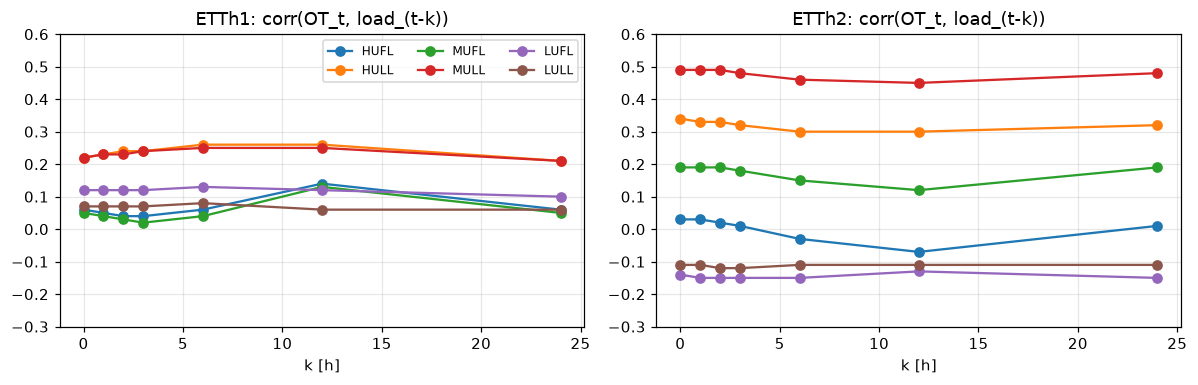

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, (n, df) in zip(axes, data.items()):
    lv = xcorr.xs((n, "level"), level=("dataset", "type"))
    for col in FEATURE_COLS: ax.plot(lags, lv.loc[col], "o-", label=col)
    ax.set_title(f"{n}: corr(OT_t, load_(t-k))"); ax.set_xlabel("k [h]"); ax.set_ylim(-0.3, 0.6)
axes[0].legend(ncol=3, fontsize=8)
plt.tight_layout(); plt.savefig(f"{FIG}/eda_load_xcorr.png"); plt.show()

## 4. 数時間で温度はどれくらい動くか — リスク警告の対象

「今の温度」が分かっていても、N 時間後にどれだけ動くかが不確実性の正体。

* ETTh1: 6h 変化の std 2.2℃、95%点 4.5℃。24h でも std 3℃ → **急激な変動は少なく、動きは緩やか**
* ETTh2: 6h 変化の std 5.6℃、95%点 12℃、最大 23℃ → **半日で 10℃ 以上動くことが日常的**にあり、事前警告の価値が大きい

In [7]:
hs = [1, 3, 6, 12, 24]
tbl = {}
for n, df in data.items():
    ok = ~flags[n]
    for h in hs:
        ch = (df.OT.shift(-h) - df.OT)[ok].dropna()
        tbl[(n, f"{h}h")] = {"std": ch.std(), "p95(|Δ|)": ch.abs().quantile(0.95), "max rise": ch.max(), "P(rise>5°C)": (ch > 5).mean()}
pd.DataFrame(tbl).T.round(3)

std  p95(|Δ|)  max rise  P(rise>5°C)
ETTh1 1h   0.925     1.900     7.949        0.001
      3h   1.595     3.306     9.285        0.004
      6h   2.236     4.517    10.482        0.016
      12h  2.917     5.909    14.351        0.038
      24h  2.952     6.190    16.743        0.031
ETTh2 1h   1.288     2.637    23.067        0.000
      3h   3.379     7.251    23.067        0.107
      6h   5.684    12.085    23.511        0.176
      12h  7.329    13.843    25.048        0.255
      24h  4.232     9.009    24.165        0.080

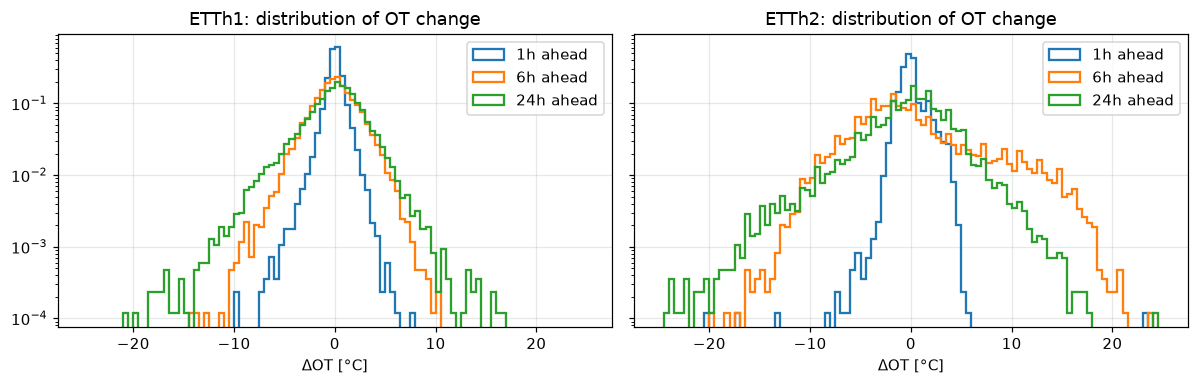

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, (n, df) in zip(axes, data.items()):
    for h in [1, 6, 24]:
        ch = (df.OT.shift(-h) - df.OT)[~flags[n]].dropna()
        ax.hist(ch, bins=np.arange(-25, 25.5, 0.5), histtype="step", lw=1.5, density=True, label=f"{h}h ahead")
    ax.set_title(f"{n}: distribution of OT change"); ax.set_xlabel("ΔOT [°C]"); ax.set_yscale("log"); ax.legend()
plt.tight_layout(); plt.savefig(f"{FIG}/eda_change_dist.png"); plt.show()

## 5. 高温はいつ起きるか — 夏季に集中、h2 は 45℃超が毎夏数百時間

現状運用の「閾値監視」がどう働いているかを見る。閾値は仮に h1: 35℃ / h2: 45℃(各データの上位 ~5%)。

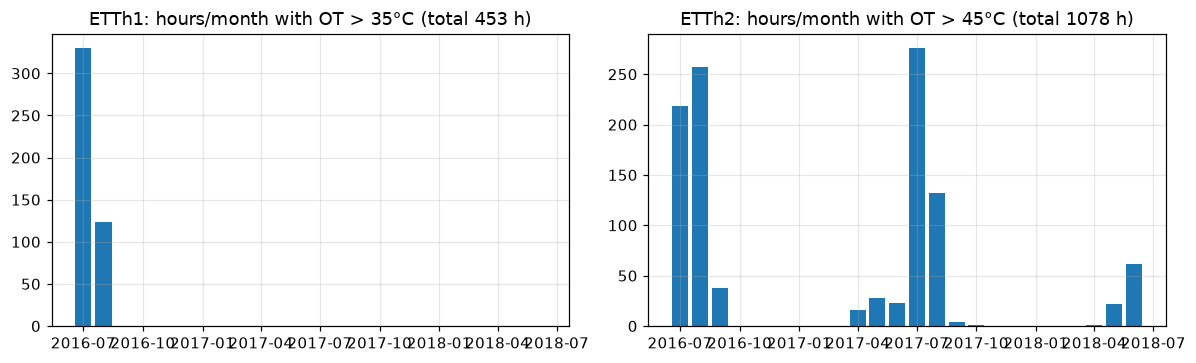

In [9]:
thr = {"ETTh1": 35, "ETTh2": 45}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, (n, df) in zip(axes, data.items()):
    over = (df.OT > thr[n]).resample("MS").sum()
    ax.bar(over.index, over.values, width=25)
    ax.set_title(f"{n}: hours/month with OT > {thr[n]}°C (total {int(over.sum())} h)")
plt.tight_layout(); plt.savefig(f"{FIG}/eda_high_temp_months.png"); plt.show()

## 6. データ品質 — 毎月 31 日は前方補完、センサ欠測もある

* **毎月 31 日の 01:00〜23:00 は全列が 00:00 の値のコピー**(h1/h2/m1 共通)。元データが欠損しており前方補完されている。両データで 322 行。
* ETTh1 2016-12-05〜07: 58 時間、全負荷ゼロ(変圧器停止)。温度は 15℃ → 1℃ へ減衰しており物理的には整合するが、通常運転とは異なる状態。
* ETTh1 2018-01: OT がちょうど 0.00 の区間が 111 行(負荷は正常)→ センサ欠測の可能性。

→ `flag_artifacts()` でフラグを付け、**評価から除外**(学習時はターゲットにしない)。

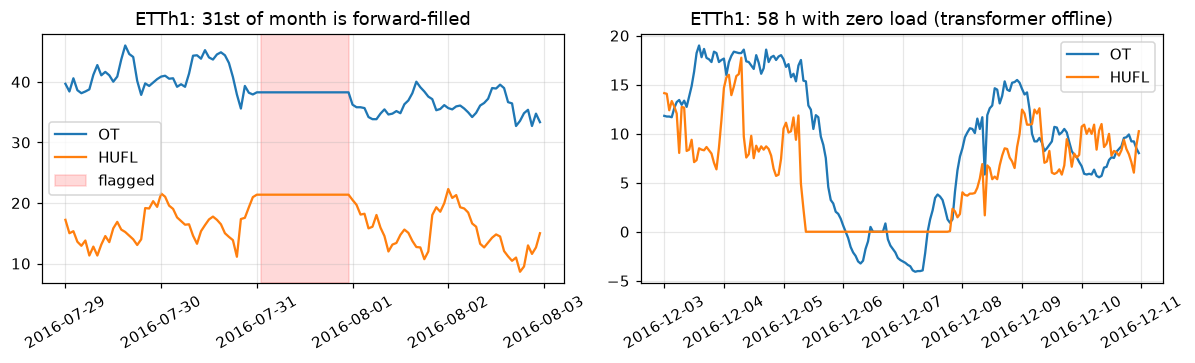

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
df = data["ETTh1"]
s = df.loc["2016-07-29":"2016-08-02"]
axes[0].plot(s.index, s.OT, label="OT"); axes[0].plot(s.index, s.HUFL, label="HUFL")
axes[0].axvspan(pd.Timestamp("2016-07-31 01:00"), pd.Timestamp("2016-07-31 23:00"), color="red", alpha=0.15, label="flagged")
axes[0].set_title("ETTh1: 31st of month is forward-filled"); axes[0].legend()
s = df.loc["2016-12-03":"2016-12-10"]
axes[1].plot(s.index, s.OT, label="OT"); axes[1].plot(s.index, s.HUFL, label="HUFL")
axes[1].set_title("ETTh1: 58 h with zero load (transformer offline)"); axes[1].legend()
for ax in axes: ax.tick_params(axis="x", labelrotation=30)
plt.tight_layout(); plt.savefig(f"{FIG}/eda_artifacts.png"); plt.show()

## EDA の示唆 → 設計への反映

| 示唆 | 設計判断 |
|---|---|
| 持続性が極めて強い(ACF lag1 > 0.99) | persistence を必ずベースラインにする。**予測対象は温度そのものではなく「現在からの変化量」**にする(レベルの学習をモデルに強いない) |
| ETTh1 は 2 年で温度レベルが大きく低下 | 木モデルは学習範囲外の値を外挿できない → 変化量ターゲットが必須。評価は複数の月にまたがるローリング方式にする |
| ETTh2 は日内周期が強い(±5℃) | 時刻特徴と 24h ラグを入れる。h2 で予測の価値が出やすい |
| 負荷との相関は弱い | 負荷ラグは補助特徴。効かなければ落とす判断もあり得る |
| 6h で 10℃ 以上動くことがある(h2) | 「N 時間先の温度」+「急上昇イベントの事前検知」を業務指標にする |
| 31 日の前方補完・センサ欠測 | 品質フラグを付け評価から除外。閾値監視でも誤報源になる点をクライアントに報告 |